## Research Question 1: Which characteristics of federal grants are most associated with budget cuts in North Carolina?

### Visualization from EDA

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
merged_df = pd.read_csv("merged_df.csv")

In [84]:
merged_df.head()

,value,savings,description_doge,total_obligation,award_amount,link,fain_key,date,agency,funding_opportunity_goals,total_obligated_amount,federal_action_obligation,non_federal_funding_amount,action_date,action_date_fiscal_year,awarding_agency_name,awarding_sub_agency_name,funding_office_name,recipient_name,recipient_parent_name,primary_place_of_performance_scope,primary_place_of_performance_country_code,primary_place_of_performance_country_name,primary_place_of_performance_state_name,cfda_title,business_types_description,action_type_description,sector
0,34998729.0,12993908.0,USAID¿S RESEARCH FOR SCALA...,22004821.0,0.0,https://usaspending.gov/aw...,7200AA19CA00041,3/1/2025,USAID,NaN,22004821.0,0.0,0.0,2023-11-01,2024.0,Agency for International D...,Agency for International D...,USAID M/OAA,FAMILY HEALTH INTERNATIONAL,NaN,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE F...,NONPROFIT WITH 501C3 IRS S...,REVISION,International Development
1,34998729.0,12993908.0,USAID¿S RESEARCH FOR SCALA...,22004821.0,50000.0,https://usaspending.gov/aw...,7200AA19CA00041,3/1/2025,USAID,NaN,22004821.0,50000.0,0.0,2024-07-17,2024.0,Agency for International D...,Agency for International D...,USAID M/OAA,FAMILY HEALTH INTERNATIONAL,NaN,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE F...,NONPROFIT WITH 501C3 IRS S...,CONTINUATION,International Development
2,34722274.0,9273274.0,TO PROVIDE SUPPORT FOR “FA...,25449000.0,0.0,https://usaspending.gov/aw...,7200AA20CA00016,3/1/2025,USAID,ORACLE.SQL.CLOB@736008DE,25449000.0,0.0,0.0,2020-09-30,2020.0,Agency for International D...,Agency for International D...,USAID GH,FAMILY HEALTH INTERNATIONAL,FAMILY HEALTH INTERNATIONAL,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE F...,NONPROFIT WITH 501C3 IRS S...,REVISION,International Development
3,34722274.0,9273274.0,TO PROVIDE SUPPORT FOR “FA...,25449000.0,0.0,https://usaspending.gov/aw...,7200AA20CA00016,3/1/2025,USAID,ORACLE.SQL.CLOB@736008DE,25449000.0,0.0,0.0,2021-02-21,2021.0,Agency for International D...,Agency for International D...,USAID GH,FAMILY HEALTH INTERNATIONAL,FAMILY HEALTH INTERNATIONAL,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE F...,NONPROFIT WITH 501C3 IRS S...,REVISION,International Development
4,140000000.0,73943882.0,THE MICROBICIDE 2021 INTRO...,66056118.0,0.0,https://usaspending.gov/aw...,7200AA21CA00011,3/1/2025,USAID,NOT APPLICABLE,66056118.0,0.0,0.0,2021-11-09,2022.0,Agency for International D...,Agency for International D...,USAID M/OAA,FAMILY HEALTH INTERNATIONAL,FAMILY HEALTH INTERNATIONAL,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE F...,NONPROFIT WITH 501C3 IRS S...,REVISION,International Development


#### Selected Features & Final Dataframe

In [88]:
pd.set_option('display.max_colwidth', 30)
merged_df.style.set_properties(**{
    'white-space': 'normal',
    'text-align': 'left'
})
feat = ['value', 'recipient_parent_name', 'savings',
    'agency',
    'cfda_title',
    'sector',
    'primary_place_of_performance_state_name',
    'total_obligated_amount',
    'action_date_fiscal_year'
]

merged_df = merged_df[feat]
merged_df.head(3)

,value,recipient_parent_name,savings,agency,cfda_title,sector,primary_place_of_performance_state_name,total_obligated_amount,action_date_fiscal_year
0,34998729.0,NaN,12993908.0,USAID,USAID FOREIGN ASSISTANCE F...,International Development,NORTH CAROLINA,22004821.0,2024.0
1,34998729.0,NaN,12993908.0,USAID,USAID FOREIGN ASSISTANCE F...,International Development,NORTH CAROLINA,22004821.0,2024.0
2,34722274.0,FAMILY HEALTH INTERNATIONAL,9273274.0,USAID,USAID FOREIGN ASSISTANCE F...,International Development,NORTH CAROLINA,25449000.0,2020.0


In [ ]:
merged_df = merged_df.rename(columns={
    'value': 'Value',
    'savings': 'Savings',
    'total_obligated_amount': 'Total Obligation',
    'recipient_parent_name': 'Recipient',
    'agency': 'Agency',
    'cfda_title': 'CFDA Title',
    'primary_place_of_performance_state_name': 'State',
    'action_date_fiscal_year': 'FY',
    'sector': 'Sector'
})

# Reorder columns
order = [
    'Value',
    'Savings',
    'Total Obligation',
    'Recipient',
    'Agency',
    'CFDA Title',
    'State',
    'FY',
    'Sector'
]

merged_df = merged_df[order]

In [92]:
merged_df['Sector'].unique()

array(['International Development', 'Justice Social Equity and Community',
       'Education', 'Science and Innovation',
       'Environment Climate Agriculture', 'Health and Human Development'],
      dtype=object)

#### Visual 1: Exploration of Target Variable

In [5]:
# Distribution of savings

merged_df['log_savings'] = np.log(merged_df['savings'])

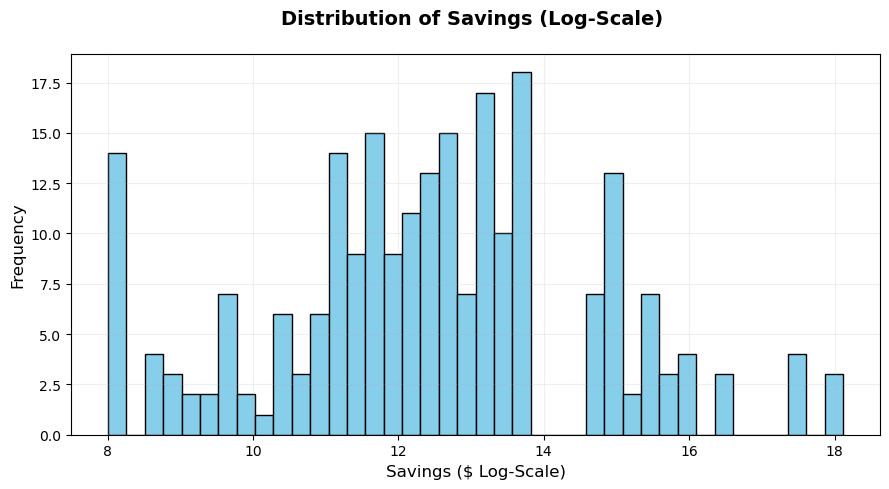

In [6]:
plt.figure(figsize=(9,5))
plt.hist(
    merged_df['log_savings'],
    bins=40,
    edgecolor='black',  
    alpha=1,
    color='skyblue'
)
plt.title("Distribution of Savings (Log-Scale) \n", fontsize=14, fontweight='bold')
plt.xlabel("Savings ($ Log-Scale)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(alpha=0.2)     # light grid
plt.tight_layout()
plt.show()

#### Visual 2: Share of Total Savings

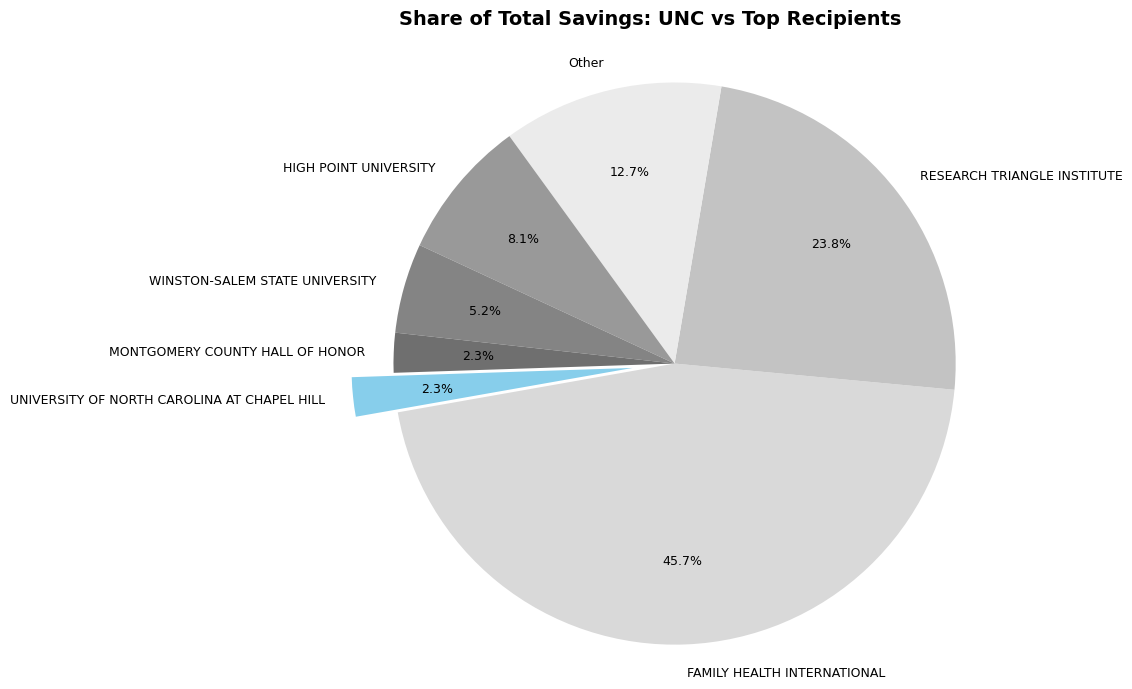

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Total savings by recipient 
recipient_totals_all = (
    merged_df
    .groupby("recipient_name", dropna=False)["savings"]
    .sum()
)

unc_name = "UNIVERSITY OF NORTH CAROLINA AT CHAPEL HILL"

if unc_name not in recipient_totals_all.index:
    raise ValueError("UNC Chapel Hill not found in dataset.")

unc_value = recipient_totals_all.loc[unc_name]

# Top 5 non-UNC
others = recipient_totals_all.drop(index=unc_name).sort_values(ascending=False)
top5 = others.head(5)
other_value = others.iloc[5:].sum()

# Assemble categories: UNC + Top5 + Other
labels = [unc_name] + list(top5.index) + ["Other"]
sizes  = [unc_value] + list(top5.values) + [other_value]

# Sort slices largest → smallest (but keep UNC recognized later)
pairs = sorted(zip(labels, sizes), key=lambda x: x[1], reverse=True)
labels_sorted, sizes_sorted = zip(*pairs)

# Grayscale by size (bigger slice = darker)
ranks = np.argsort(-np.array(sizes_sorted))  # rank slices by size
grey_levels = np.linspace(0.85, 0.35, len(sizes_sorted))  # light → darker
grey_shades = grey_levels[ranks]

colors = []
for i, lab in enumerate(labels_sorted):
    if lab == unc_name:
        colors.append("skyblue")       # UNC highlighted
    else:
        colors.append((grey_shades[i], grey_shades[i], grey_shades[i]))

# Make "Other" the lightest grey
for i, lab in enumerate(labels_sorted):
    if lab == "Other":
        colors[i] = (0.92, 0.92, 0.92)

# Pie chart
start_angle = -170

explode = [0.15 if lab == unc_name else 0 for lab in labels_sorted]

plt.figure(figsize=(10, 7))

plt.pie(
    sizes_sorted,
    labels=labels_sorted,
    colors=colors,
    explode = explode,
    autopct='%1.1f%%',
    startangle=start_angle,
    pctdistance=0.7,
    textprops={'fontsize': 9}
)

plt.title("Share of Total Savings: UNC vs Top Recipients \n",
          fontsize=14, fontweight='bold')

plt.axis('equal')
plt.tight_layout()
plt.show()

## Research Question 2 (Only models are here)

In [8]:
merged_copy= merged_df.copy()

In [9]:
merged_copy = merged_copy.drop(columns = ['link', 'date', 'funding_opportunity_goals', 
                            'total_obligation', 'action_date', 'primary_place_of_performance_country_code', 
                            'primary_place_of_performance_country_name', 'primary_place_of_performance_state_name', 
                            'federal_action_obligation', 'non_federal_funding_amount'])

In [10]:
merged_copy.columns

Index(['value', 'savings', 'description_doge', 'award_amount', 'fain_key',
       'agency', 'total_obligated_amount', 'action_date_fiscal_year',
       'awarding_agency_name', 'awarding_sub_agency_name',
       'funding_office_name', 'recipient_name', 'recipient_parent_name',
       'primary_place_of_performance_scope', 'cfda_title',
       'business_types_description', 'action_type_description', 'sector',
       'log_savings'],
      dtype='object')

In [11]:
unc_df = (
    merged_copy[merged_copy['recipient_parent_name'] == 'THE UNIVERSITY OF NORTH CAROLINA']
    .sort_values(by='savings', ascending=False)
)
unc_df.head()

,value,savings,description_doge,award_amount,fain_key,agency,total_obligated_amount,action_date_fiscal_year,awarding_agency_name,awarding_sub_agency_name,funding_office_name,recipient_name,recipient_parent_name,primary_place_of_performance_scope,cfda_title,business_types_description,action_type_description,sector,log_savings
231,4228801.0,3092663.0,WINSTON-SALEM TEACH TQP RESIDENCY PROGRAM,698034.0,S336S220071,Department Of Education,2534784.0,2023.0,Department of Education,Department of Education,OFC OF ELEMENTARY AND SECONDARY EDU,WINSTON-SALEM STATE UNIVERSITY,THE UNIVERSITY OF NORTH CAROLINA,SINGLE ZIP CODE,TEACHER QUALITY PARTNERSHIP GRANTS,PUBLIC/STATE CONTROLLED INSTITUTION OF HIGHER ...,CONTINUATION,Education,14.944543
230,4228801.0,3092663.0,WINSTON-SALEM TEACH TQP RESIDENCY PROGRAM,114424.0,S336S220071,Department Of Education,2534784.0,2023.0,Department of Education,Department of Education,OFC OF ELEMENTARY AND SECONDARY EDU,WINSTON-SALEM STATE UNIVERSITY,THE UNIVERSITY OF NORTH CAROLINA,SINGLE ZIP CODE,TEACHER QUALITY PARTNERSHIP GRANTS,PUBLIC/STATE CONTROLLED INSTITUTION OF HIGHER ...,REVISION,Education,14.944543
229,4228801.0,3092663.0,WINSTON-SALEM TEACH TQP RESIDENCY PROGRAM,372107.0,S336S220071,Department Of Education,2534784.0,2022.0,Department of Education,Department of Education,OFC OF ELEMENTARY AND SECONDARY EDU,WINSTON-SALEM STATE UNIVERSITY,THE UNIVERSITY OF NORTH CAROLINA,SINGLE ZIP CODE,TEACHER QUALITY PARTNERSHIP GRANTS,PUBLIC/STATE CONTROLLED INSTITUTION OF HIGHER ...,REVISION,Education,14.944543
228,4228801.0,3092663.0,WINSTON-SALEM TEACH TQP RESIDENCY PROGRAM,340895.0,S336S220071,Department Of Education,2534784.0,2022.0,Department of Education,Department of Education,OFC OF ELEMENTARY AND SECONDARY EDU,WINSTON-SALEM STATE UNIVERSITY,THE UNIVERSITY OF NORTH CAROLINA,SINGLE ZIP CODE,TEACHER QUALITY PARTNERSHIP GRANTS,PUBLIC/STATE CONTROLLED INSTITUTION OF HIGHER ...,NEW,Education,14.944543
34,4228801.0,3092662.6,WINSTON-SALEM TEACH TQP RESIDENCY PROGRAM,340895.0,S336S220071,Department Of Education,2534784.0,2022.0,Department of Education,Department of Education,OFC OF ELEMENTARY AND SECONDARY EDU,WINSTON-SALEM STATE UNIVERSITY,THE UNIVERSITY OF NORTH CAROLINA,SINGLE ZIP CODE,TEACHER QUALITY PARTNERSHIP GRANTS,PUBLIC/STATE CONTROLLED INSTITUTION OF HIGHER ...,NEW,Education,14.944543


In [12]:
unc_df.shape

(83, 19)

## Summary of EDA:  
1. Education receives many awards (size is to be determined).   
Hypothesis: cuts might be concentrated in fewer large projects, not spread evenly.  

2. Massive total_Savings: microbicide program, USAID projects, big education residency programs.   
That suggests heavy vulnerability of specific types of programs.    

3. Major role of USAID and International Development. USAID rarely funds domestic education. so why?

## Research Question 2: Which types of UNC projects are at highest risk of experiencing large federal funding cuts?

Why this matters (for UNC stakeholders):
1. Helps research offices identify vulnerable grants
2. Guides diversification of funding streams
4. Allows departments to anticipate reduced student support, RA positions, or research capacity
5. Helps leadership protect priority areas

Target variable: define binary outcome using existing "savings"    
In this analysis, high risk refers to UNC projects that experienced larger-than-typical federal funding cuts based on their recorded “savings” amounts. Because savings is a continuous value, we converted it into a binary category to support classification.
Specifically, we labeled a project as high risk if its savings amount was greater than or equal to the median savings among all UNC projects in our dataset. Projects below the median were labeled as low risk.
This approach defines “high risk” as the group of projects that historically experienced disproportionately large funding reductions, enabling us to model vulnerability using classification techniques rather than predicting exact dollar amounts.

Performance metrics: accuracy, predcidion/recall, ROC-AUC

BASIC QUESTION: Will this UNC project be high-risk of getting cut or not?

### Models: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting   

In [14]:
unc_df.columns

Index(['value', 'savings', 'description_doge', 'award_amount', 'fain_key',
       'agency', 'total_obligated_amount', 'action_date_fiscal_year',
       'awarding_agency_name', 'awarding_sub_agency_name',
       'funding_office_name', 'recipient_name', 'recipient_parent_name',
       'primary_place_of_performance_scope', 'cfda_title',
       'business_types_description', 'action_type_description', 'sector',
       'log_savings'],
      dtype='object')

#### Define high_risk

In [ ]:
unc = merged_copy[merged_copy['recipient_parent_name'] == 'THE UNIVERSITY OF NORTH CAROLINA'].copy()
median_savings = unc['savings'].median()
unc['high_risk'] = (unc['savings'] >= median_savings).astype(int)
print("Median savings used as high-risk threshold:", median_savings)

Median savings used as high-risk threshold: 216340.77


In [16]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

features = [
    'agency',
    'awarding_agency_name',
    'awarding_sub_agency_name',
    'funding_office_name',
    'cfda_title',
    'business_types_description',
    'action_type_description',
    'sector',
    'primary_place_of_performance_scope',
    'award_amount',
    'total_obligated_amount',
    'action_date_fiscal_year'
]

X = unc[features].copy()
y = unc['high_risk'].copy()

# treat fiscal year as categorical
X['action_date_fiscal_year'] = X['action_date_fiscal_year'].astype(str)

categorical = [
    'agency',
    'awarding_agency_name',
    'awarding_sub_agency_name',
    'funding_office_name',
    'cfda_title',
    'business_types_description',
    'action_type_description',
    'sector',
    'primary_place_of_performance_scope',
    'action_date_fiscal_year'
]

numeric = [
    'award_amount',
    'total_obligated_amount'
]

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', 'passthrough', numeric)
    ]
)

In [ ]:
# Helper Function to find best hyperparameters

from sklearn.model_selection import cross_val_score

def test_params(model_name, estimator, param_list):
    results = []
    for params in param_list:
        estimator.set_params(**params)
        pipe = Pipeline([
            ('preprocess', preprocess),
            ('model', estimator)
        ])
        scores = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc')
        results.append({
            'params': params,
            'mean_auc': scores.mean(),
            'std_auc': scores.std()
        })
    best = max(results, key=lambda x: x['mean_auc'])
    print(f"Best for {model_name}:", best)
    return best

results_list = []

In [19]:
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(max_iter=1000)

log_param_list = [
    {'C': 0.01},
    {'C': 0.1},
    {'C': 1.0},
    {'C': 10.0}
]

best_log = test_params("Logistic Regression", log_clf, log_param_list)
results_list.append(["Logistic Regression", best_log['params'], best_log['mean_auc'], best_log['std_auc']])

Best for Logistic Regression: {'params': {'C': 0.01}, 'mean_auc': 0.7954861111111111, 'std_auc': 0.26220313166147813}


In [20]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42)

tree_param_list = [
    {'max_depth': 2},
    {'max_depth': 3},
    {'max_depth': 4},
    {'max_depth': 5}
]

best_tree = test_params("Decision Tree", tree_clf, tree_param_list)
results_list.append(["Decision Tree", best_tree['params'], best_tree['mean_auc'], best_tree['std_auc']])

Best for Decision Tree: {'params': {'max_depth': 2}, 'mean_auc': 0.8111111111111111, 'std_auc': 0.2393728946978947}


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)

rf_param_list = [
    {'max_depth': 3, 'n_estimators': 100},
    {'max_depth': 5, 'n_estimators': 100},
    {'max_depth': 5, 'n_estimators': 200},
]

best_rf = test_params("Random Forest", rf_clf, rf_param_list)
results_list.append(["Random Forest", best_rf['params'], best_rf['mean_auc'], best_rf['std_auc']])

Best for Random Forest: {'params': {'max_depth': 3, 'n_estimators': 100}, 'mean_auc': 0.836111111111111, 'std_auc': 0.23527630197621888}


In [22]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(random_state=42)

gb_param_list = [
    {'max_depth': 2, 'learning_rate': 0.05},
    {'max_depth': 3, 'learning_rate': 0.05},
    {'max_depth': 3, 'learning_rate': 0.1}
]

best_gb = test_params("Gradient Boosting", gb_clf, gb_param_list)
results_list.append(["Gradient Boosting", best_gb['params'], best_gb['mean_auc'], best_gb['std_auc']])

Best for Gradient Boosting: {'params': {'max_depth': 2, 'learning_rate': 0.05}, 'mean_auc': 0.8527777777777779, 'std_auc': 0.1454956407645311}


In [47]:
results_df = pd.DataFrame(results_list, columns=["Model", "Best Parameters", "Mean AUC", "Std AUC"])
results_df

,Model,Best Parameters,Mean AUC,Std AUC
0,Logistic Regression,{'C': 0.01},0.795486,0.262203
1,Decision Tree,{'max_depth': 2},0.811111,0.239373
2,Random Forest,"{'max_depth': 3, 'n_estimators': 100}",0.836111,0.235276
3,Gradient Boosting,"{'max_depth': 2, 'learning_rate': 0.05}",0.852778,0.145496


In [24]:
print("Dataset shape:", X.shape)
print("\nClass distribution (high_risk):")
print(y.value_counts(normalize=True))

Dataset shape: (83, 12)

Class distribution (high_risk):
high_risk
1    0.518072
0    0.481928
Name: proportion, dtype: float64


### Feature Importance

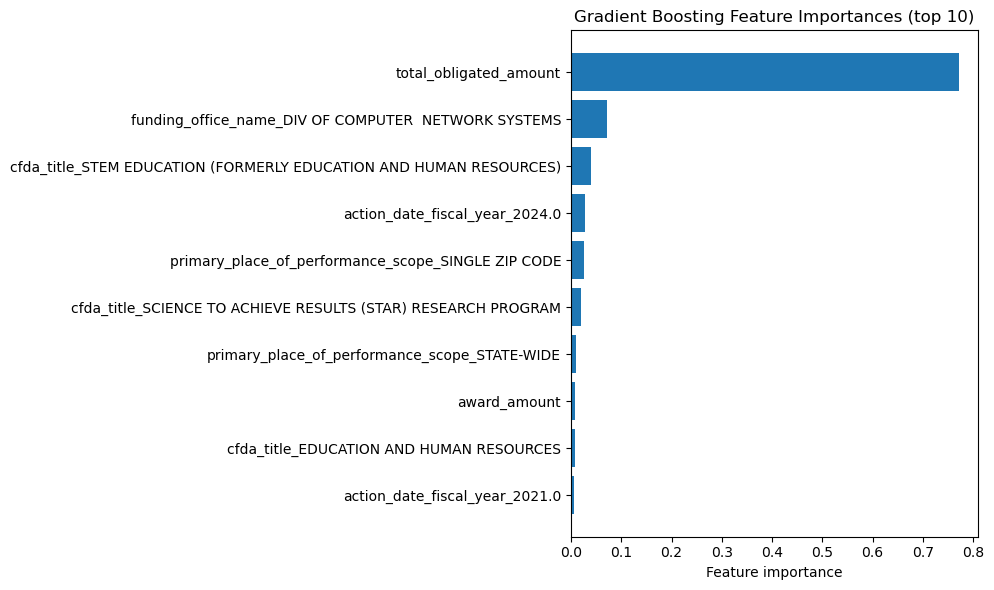

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier


gb_best = GradientBoostingClassifier(
    random_state=42,
    **best_gb['params']  # {'max_depth': 2, 'learning_rate': 0.05}
)

gb_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', gb_best)
])

gb_pipe.fit(X, y)


ohe = gb_pipe.named_steps['preprocess'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical)

# Numeric features are passed through unchanged and come after the cats
all_feature_names = np.concatenate([cat_feature_names, numeric])


gb_model = gb_pipe.named_steps['model']
importances = gb_model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)


top_k = 10  # change if you want more/less
top_feat = feat_imp.head(top_k).iloc[::-1]  # reverse for nicer barh

plt.figure(figsize=(10, 6))
plt.barh(top_feat['feature'], top_feat['importance'])
plt.xlabel('Feature importance')
plt.title('Gradient Boosting Feature Importances (top 10)')
plt.tight_layout()
plt.show()

### Using model to predict programs at high-risk of being cut

In [ ]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

gb_best = GradientBoostingClassifier(
    random_state=42,
    max_depth=2,
    learning_rate=0.05   # your best params
)

gb_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', gb_best)
])

gb_pipe.fit(X, y)

unc['pred_high_risk_prob'] = gb_pipe.predict_proba(X)[:, 1]


threshold = 0.7
high_risk_awards = unc[unc['pred_high_risk_prob'] >= threshold].copy()

high_risk_awards = high_risk_awards[
    ['fain_key', 'cfda_title', 'funding_office_name',
     'total_obligated_amount', 'pred_high_risk_prob']
].sort_values('pred_high_risk_prob', ascending=False)

print("Individual UNC awards predicted high-risk:")
high_risk_awards.head(10)

Individual UNC awards predicted high-risk:


,fain_key,cfda_title,funding_office_name,total_obligated_amount,pred_high_risk_prob
69,2101169,STEM EDUCATION (FORMERLY EDUCATION AND HUMAN R...,DIV OF RESEARCH ON LEARNING IN,1611921.0,0.980445
102,2313996,STEM EDUCATION (FORMERLY EDUCATION AND HUMAN R...,DIV OF RESEARCH ON LEARNING IN,1123487.0,0.980445
16,S336S200015,TEACHER QUALITY PARTNERSHIP GRANTS,OFC OF ELEMENTARY AND SECONDARY EDU,2371270.0,0.971159
229,S336S220071,TEACHER QUALITY PARTNERSHIP GRANTS,OFC OF ELEMENTARY AND SECONDARY EDU,2534784.0,0.971159
21,S336S220004,TEACHER QUALITY PARTNERSHIP GRANTS,OFC OF ELEMENTARY AND SECONDARY EDU,1273070.0,0.971159
228,S336S220071,TEACHER QUALITY PARTNERSHIP GRANTS,OFC OF ELEMENTARY AND SECONDARY EDU,2534784.0,0.971159
188,2321633,STEM EDUCATION (FORMERLY EDUCATION AND HUMAN R...,DIVISION OF UNDERGRADUATE EDUCATION,1000000.0,0.971159
27,S336S220017,TEACHER QUALITY PARTNERSHIP GRANTS,OFC OF ELEMENTARY AND SECONDARY EDU,2495619.0,0.971159
34,S336S220071,TEACHER QUALITY PARTNERSHIP GRANTS,OFC OF ELEMENTARY AND SECONDARY EDU,2534784.0,0.971159
35,S336S220071,TEACHER QUALITY PARTNERSHIP GRANTS,OFC OF ELEMENTARY AND SECONDARY EDU,2534784.0,0.971159


In [ ]:

program_risk = (
    unc.groupby('cfda_title')
       .agg(
           Number_of_Awards=('fain_key', 'nunique'),
           Mean_Predicted_Risk=('pred_high_risk_prob', 'mean'),
           Maximum_Predicted_Risk=('pred_high_risk_prob', 'max')
       )
       .sort_values('Mean_Predicted_Risk', ascending=False)
)

# rename cfda_title index to a column name
program_risk.index.name = 'CFDA Title'

print("\nUNC programs (CFDA titles) with highest predicted risk:")
program_risk.head(10)


UNC programs (CFDA titles) with highest predicted risk:


,Number_of_Awards,Mean_Predicted_Risk,Maximum_Predicted_Risk
CFDA Title,,,
"NSF TECHNOLOGY, INNOVATION, AND PARTNERSHIPS",1,0.969099,0.969099
TEACHER QUALITY PARTNERSHIP GRANTS,4,0.964138,0.971159
OFFICE OF RESEARCH AND DEVELOPMENT CONSOLIDATED RESEARCH/TRAINING/FELLOWSHIPS,1,0.963319,0.969099
STEM EDUCATION (FORMERLY EDUCATION AND HUMAN RESOURCES),9,0.799015,0.980445
COMPUTER AND INFORMATION SCIENCE AND ENGINEERING,2,0.464034,0.787830
EDUCATION AND HUMAN RESOURCES,13,0.351334,0.965623
SCIENCE TO ACHIEVE RESULTS (STAR) RESEARCH PROGRAM,2,0.161546,0.239309
"SOCIAL, BEHAVIORAL, AND ECONOMIC SCIENCES",6,0.159188,0.685752
CITIZENSHIP EDUCATION AND TRAINING,1,0.055482,0.055482


### Visualizing the GB model

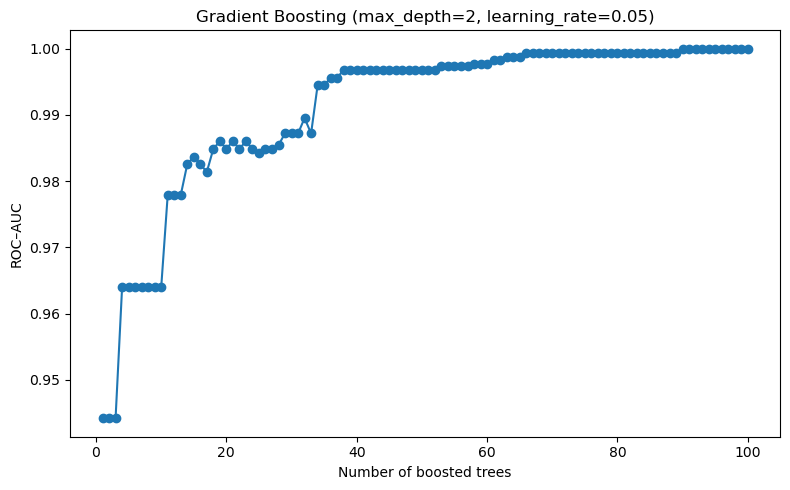

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np

# refit GB with best params
best_params = best_gb['params']
gb_best = GradientBoostingClassifier(random_state=42, **best_params)

gb_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', gb_best)
])

gb_pipe.fit(X, y)

# preprocessed features
X_pre = gb_pipe.named_steps['preprocess'].transform(X)
model = gb_pipe.named_steps['model']

auc_scores = []
num_trees = []

for i, proba in enumerate(model.staged_predict_proba(X_pre), start=1):
    p = proba[:, 1]               # probability of positive class
    auc = roc_auc_score(y, p)
    auc_scores.append(auc)
    num_trees.append(i)

# plot
plt.figure(figsize=(8,5))
plt.plot(num_trees, auc_scores, marker='o')
plt.xlabel("Number of boosted trees")
plt.ylabel("ROC–AUC")
plt.title(f"Gradient Boosting (max_depth={best_params['max_depth']}, "
          f"learning_rate={best_params['learning_rate']})")
plt.tight_layout()
plt.show()